<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/Catalina_Nunez_Yanez_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Fuga de Clientes (Churn)
**BIY7121 Minería de Datos — DuocUC**  
**Alumna:** Catalina Núñez Yáñez

## 1. Business Understanding

Una empresa de telecomunicaciones en California quiere identificar qué clientes están en riesgo de irse antes de que lo hagan. Tienen datos históricos de 7.043 usuarios y el objetivo es encontrar patrones que permitan actuar a tiempo.

Perder un cliente sale caro — conseguir uno nuevo es mucho más costoso que retener uno actual. Por eso tiene sentido construir un modelo que prediga el churn con anticipación y le dé al equipo de marketing la oportunidad de intervenir.

**Variables que deberían importar más:**
- **Contract**: si el contrato es mes a mes, el cliente se puede ir cuando quiera.
- **tenure**: a más tiempo en la empresa, menos probable que se vaya
- **MonthlyCharges**: si paga mucho y no percibe valor, probablemente se va.
- **InternetService**: los de fibra óptica tienen más opciones en el mercado.

## 2. Carga e Ingesta de Datos

In [ ]:
# Librerías necesarias para todo el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

In [ ]:
# Cargamos el dataset y revisamos su tamaño
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
df.head()

Filas: 7043, Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Verificamos los tipos de datos de cada columna
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
# TotalCharges viene como object — hay filas con espacios en blanco
# La convertimos manualmente a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('TotalCharges convertida a:', df['TotalCharges'].dtype)

TotalCharges convertida a: float64


## 3. Data Understanding — EDA
### 3.1 Limpieza de Datos — Valores Nulos

In [ ]:
# Identificamos valores nulos por columna
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Solo TotalCharges tiene 11 nulos — son clientes con tenure=0 sin cobros aún
# 11 filas sobre 7043 no afecta, las eliminamos
df.dropna(inplace=True)
print(f'Dataset después de limpiar: {df.shape[0]} filas')

Dataset después de limpiar: 7032 filas


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Porcentaje de fuga: 26.6%


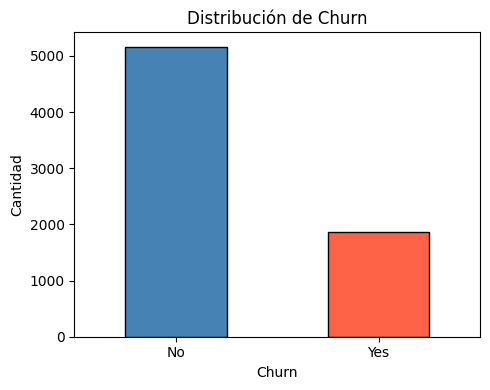

In [ ]:
# Distribución de la variable objetivo (Churn)
print(df['Churn'].value_counts())
print(f'\nPorcentaje de fuga: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

plt.figure(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Nota: Solo el 26.6% hizo churn — hay desbalance. Lo trataremos más adelante con SMOTE.

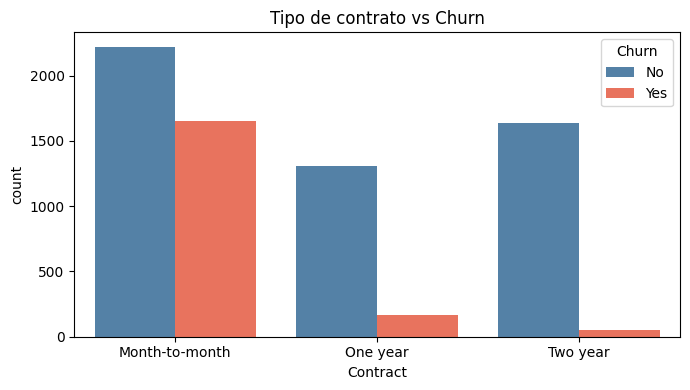

In [ ]:
# Tipo de contrato vs churn
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['steelblue','tomato'])
plt.title('Tipo de contrato vs Churn')
plt.tight_layout()
plt.show()

Nota: Los contratos mes a mes concentran casi toda la fuga. Los de 1 o 2 años casi no hacen churn.

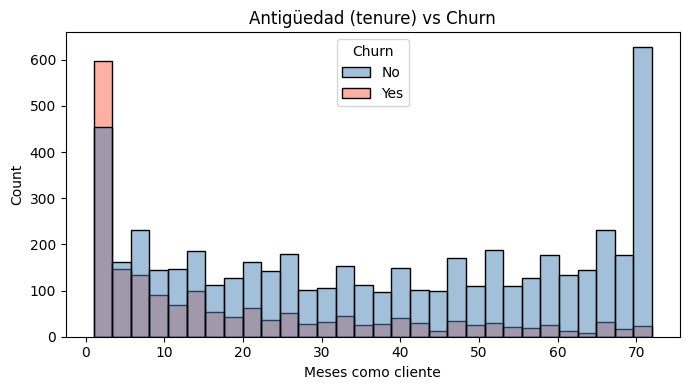

In [ ]:
# Antigüedad del cliente vs churn
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['steelblue','tomato'])
plt.title('Antigüedad (tenure) vs Churn')
plt.xlabel('Meses como cliente')
plt.tight_layout()
plt.show()

Nota: La mayoría de los que se van llevan menos de 12 meses. Clientes más antiguos tienden a quedarse.

In [ ]:
# Estadísticas generales de las variables numéricas
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


### 3.2 Detección de Outliers — Boxplots e IQR

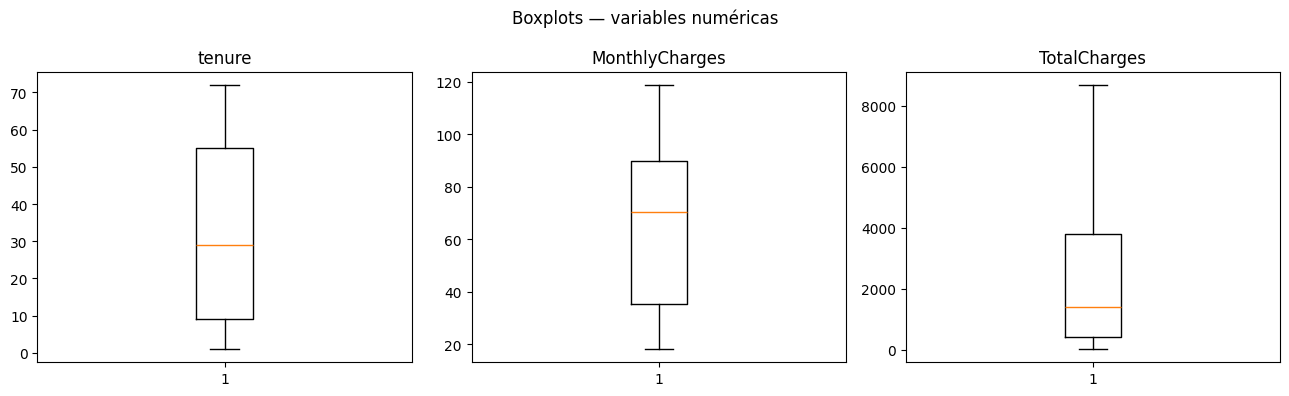

In [ ]:
# Visualizamos los boxplots para detectar valores atípicos
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.suptitle('Boxplots — variables numéricas')
plt.tight_layout()
plt.show()

In [ ]:
# Cálculo de outliers con método IQR: IQR = Q3 - Q1
# Límites: [Q1 - 1.5*IQR , Q3 + 1.5*IQR]
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out = len(df[(df[col] < lim_inf) | (df[col] > lim_sup)])
    print(f'{col}: {n_out} outliers | rango normal [{lim_inf:.1f}, {lim_sup:.1f}]')

tenure: 0 outliers | rango normal [-60.0, 124.0]
MonthlyCharges: 0 outliers | rango normal [-45.8, 171.3]
TotalCharges: 0 outliers | rango normal [-4688.5, 8884.7]


Nota: No hay outliers fuera del rango IQR. Valores altos en TotalCharges o MonthlyCharges corresponden a clientes con planes premium o de larga data — son datos válidos, no errores. No se eliminan.

### 3.3 Análisis de Correlación

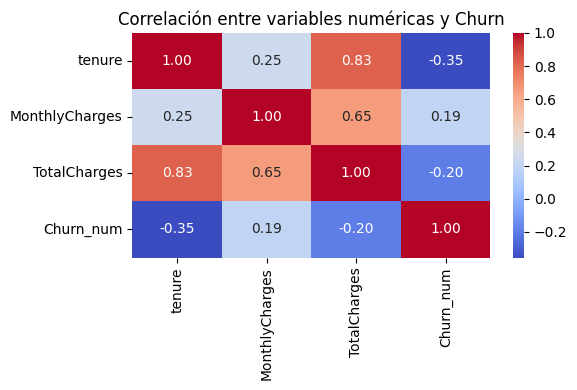

In [ ]:
# Matriz de correlación entre variables numéricas y Churn
# Convertimos Churn a número para incluirlo
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

corr = df_corr[['tenure','MonthlyCharges','TotalCharges','Churn_num']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre variables numéricas y Churn')
plt.tight_layout()
plt.show()

Nota: tenure tiene correlación negativa con Churn (-0.35) — más tiempo en la empresa, menos probabilidad de irse. MonthlyCharges tiene correlación positiva (0.19) — los que pagan más tienden a irse más.

También se observa que tenure y TotalCharges tienen correlación alta (0.83) — esto es esperable porque TotalCharges es básicamente tenure × MonthlyCharges. Para evitar multicolinealidad en los modelos, vamos a excluir TotalCharges.

## 4. Data Preparation
### 4.1 Transformación de Variables

In [ ]:
# Eliminamos customerID (solo identificador) y TotalCharges (multicolinealidad con tenure)
df_model = df.drop(columns=['customerID', 'TotalCharges'])

X = df_model.drop(columns=['Churn'])
y = (df_model['Churn'] == 'Yes').astype(int)  # 1 = se fue, 0 = se quedó

print('Variables para el modelo:', X.shape[1])
print(y.value_counts())

Variables para el modelo: 18
Churn
0    5163
1    1869
Name: count, dtype: int64


In [ ]:
# Label Encoding para columnas con solo 2 valores posibles
le = LabelEncoder()
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling',
               'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies']

for col in binary_cols:
    X[col] = le.fit_transform(X[col])

# One-Hot Encoding para columnas con más de 2 categorías
X = pd.get_dummies(X, columns=['InternetService','Contract','PaymentMethod'], drop_first=True)

print('Total columnas después de transformar:', X.shape[1])
print(X.dtypes)

Total columnas después de transformar: 22
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year                           bool
Contract_Two year                           bool
PaymentMethod_Credit card (

In [ ]:
# División train/test — 70% entrenamiento, 30% prueba
# stratify=y para mantener la proporción de clases en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')

Train: 4922 filas | Test: 2110 filas


In [ ]:
# StandardScaler: normaliza las variables a la misma escala
# Obligatorio para SVM y Regresión Logística
# fit solo en train para no contaminar el test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalado aplicado correctamente')

Escalado aplicado correctamente


### 4.2 Manejo del Desbalance de Clases — SMOTE

El dataset tiene 74% de clientes que no hicieron churn y solo 26% que sí. Si entrenamos así, los modelos aprenden a predecir siempre "no se va" y de todas formas tienen ~74% de accuracy — pero eso no sirve para el negocio.

**SMOTE** (Synthetic Minority Oversampling Technique) genera ejemplos sintéticos de la clase minoritaria para equilibrar el dataset antes de entrenar.

In [ ]:
# Aplicamos SMOTE solo sobre el set de entrenamiento
print('Distribución ANTES de SMOTE:')
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('\nDistribución DESPUÉS de SMOTE:')
print(pd.Series(y_train_sm).value_counts())

Distribución ANTES de SMOTE:
Churn
0    3614
1    1308
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
Churn
1    3614
0    3614
Name: count, dtype: int64


## 5. Modeling & Evaluation — Entrenamiento de Modelos

Se implementan los tres modelos requeridos: **Regresión Logística**, **SVM** y **Árbol de Decisión**. Cada uno se evalúa con matriz de confusión, Accuracy y F1-Score.

In [ ]:
# Función reutilizable para entrenar y evaluar cada modelo
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)

    acc = accuracy_score(y_te, pred)
    f1  = f1_score(y_te, pred)

    print(f'\n--- {nombre} ---')
    print(f'Accuracy : {acc:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print(classification_report(y_te, pred, target_names=['Se queda','Se va']))

    # Matriz de confusión
    cm = confusion_matrix(y_te, pred)
    plt.figure(figsize=(5,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: queda','Pred: se va'],
                yticklabels=['Real: queda','Real: se va'])
    plt.title(f'Matriz de Confusión — {nombre}')
    plt.tight_layout()
    plt.show()

    return modelo, acc, f1, pred

### 5.1 Modelo 1 — Regresión Logística


--- Regresión Logística ---
Accuracy : 0.7464
F1-Score : 0.6148
              precision    recall  f1-score   support

    Se queda       0.90      0.74      0.81      1549
       Se va       0.52      0.76      0.61       561

    accuracy                           0.75      2110
   macro avg       0.71      0.75      0.71      2110
weighted avg       0.79      0.75      0.76      2110



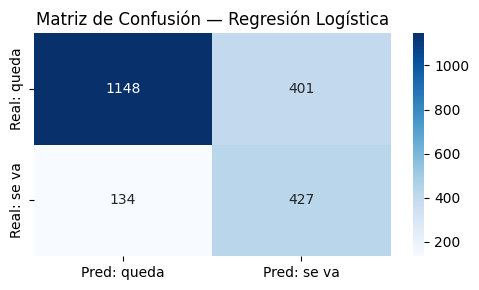

In [ ]:
# Regresión Logística: calcula la probabilidad de que un cliente se vaya
# C=0.5 aplica regularización para evitar sobreajuste
lr = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
lr_model, lr_acc, lr_f1, lr_pred = evaluar(
    'Regresión Logística', lr, X_train_sm, y_train_sm, X_test_scaled, y_test
)

### 5.2 Modelo 2 — SVM


--- SVM ---
Accuracy : 0.7578
F1-Score : 0.6090
              precision    recall  f1-score   support

    Se queda       0.88      0.78      0.82      1549
       Se va       0.53      0.71      0.61       561

    accuracy                           0.76      2110
   macro avg       0.71      0.74      0.72      2110
weighted avg       0.79      0.76      0.77      2110



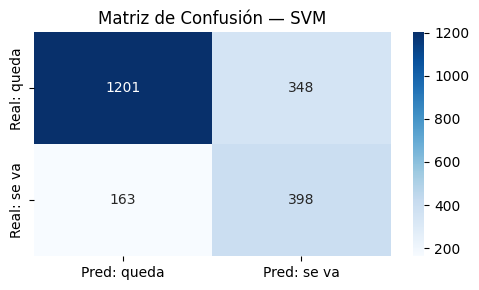

In [ ]:
# SVM busca el hiperplano que mejor separa las dos clases
# kernel rbf para datos no linealmente separables
# Requiere datos escalados — ya aplicamos StandardScaler
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model, svm_acc, svm_f1, svm_pred = evaluar(
    'SVM', svm, X_train_sm, y_train_sm, X_test_scaled, y_test
)

### 5.3 Modelo 3 — Árbol de Decisión


--- Árbol de Decisión ---
Accuracy : 0.7536
F1-Score : 0.6006
              precision    recall  f1-score   support

    Se queda       0.88      0.77      0.82      1549
       Se va       0.53      0.70      0.60       561

    accuracy                           0.75      2110
   macro avg       0.70      0.74      0.71      2110
weighted avg       0.78      0.75      0.76      2110



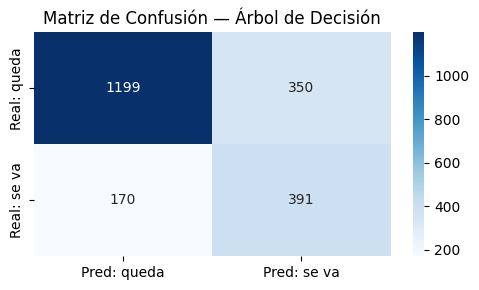

In [ ]:
# Árbol de Decisión: divide los datos con preguntas IF/ELSE
# criterion='entropy' usa ganancia de información para elegir los cortes
# max_depth=5 limita la profundidad para evitar sobreajuste
tree = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
tree_model, tree_acc, tree_f1, tree_pred = evaluar(
    'Árbol de Decisión', tree, X_train_sm, y_train_sm, X_test_scaled, y_test
)

### 5.4 Comparación de los tres modelos

             Modelo  Accuracy  F1-Score
Regresión Logística  0.746445  0.614831
                SVM  0.757820  0.609028
  Árbol de Decisión  0.753555  0.600614


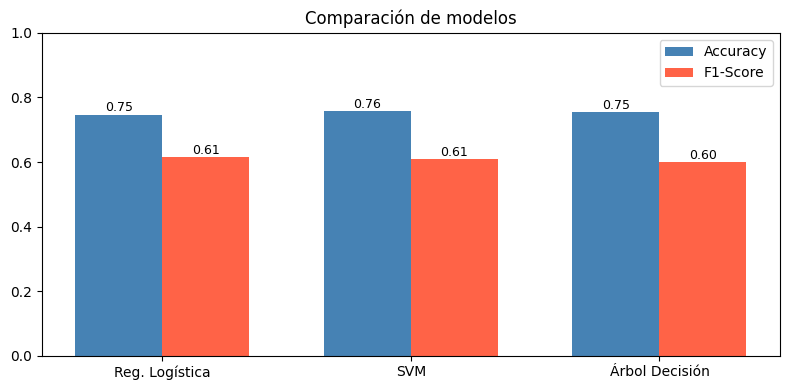

In [ ]:
# Tabla comparativa de Accuracy y F1-Score
resultados = pd.DataFrame({
    'Modelo'  : ['Regresión Logística', 'SVM', 'Árbol de Decisión'],
    'Accuracy': [lr_acc, svm_acc, tree_acc],
    'F1-Score': [lr_f1,  svm_f1,  tree_f1]
})
print(resultados.to_string(index=False))

# Gráfico comparativo
x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(8,4))
b1 = ax.bar(x - w/2, resultados['Accuracy'], w, label='Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, resultados['F1-Score'], w, label='F1-Score',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(['Reg. Logística','SVM','Árbol Decisión'])
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Comparación de modelos')
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{b.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Nota: SVM tiene el mejor accuracy (76%), pero la Regresión Logística detecta más casos reales de churn (Recall más alto). En contexto de negocio, detectar al que se va importa más que el accuracy general.

### 5.5 Identificación de Variables Influyentes

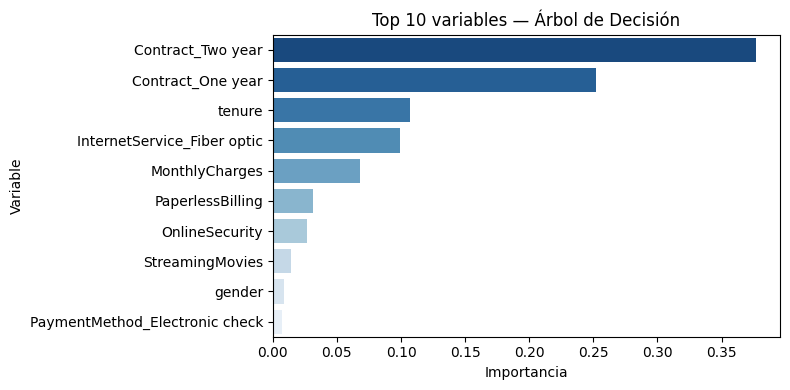

                      Variable  Importancia
             Contract_Two year     0.376743
             Contract_One year     0.251853
                        tenure     0.106995
   InternetService_Fiber optic     0.099537
                MonthlyCharges     0.067881
              PaperlessBilling     0.031160
                OnlineSecurity     0.026889
               StreamingMovies     0.014587
                        gender     0.008675
PaymentMethod_Electronic check     0.007575


In [ ]:
# Feature importance del Árbol de Decisión
# Muestra qué variables usó más el modelo para tomar decisiones
importancias = pd.DataFrame({
    'Variable'   : X.columns,
    'Importancia': tree_model.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(data=importancias, x='Importancia', y='Variable', palette='Blues_r')
plt.title('Top 10 variables — Árbol de Decisión')
plt.tight_layout()
plt.show()

print(importancias.to_string(index=False))

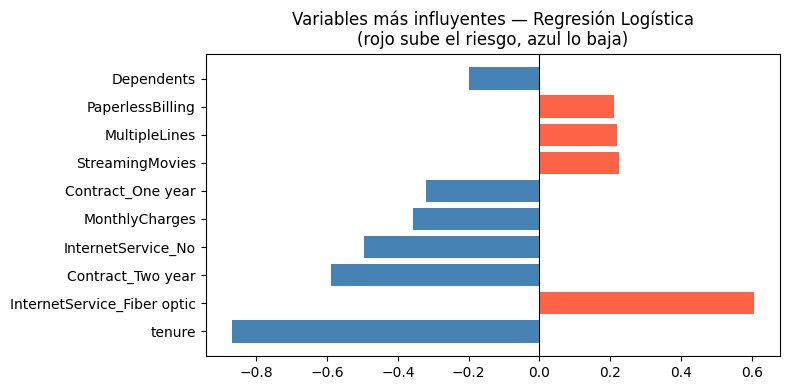

In [ ]:
# Coeficientes de la Regresión Logística
# Valor positivo = sube el riesgo de churn
# Valor negativo = lo reduce
coefs = pd.DataFrame({
    'Variable'   : X.columns,
    'Coeficiente': lr_model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(10)

colores = ['tomato' if c > 0 else 'steelblue' for c in coefs['Coeficiente']]
plt.figure(figsize=(8,4))
plt.barh(coefs['Variable'], coefs['Coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Variables más influyentes — Regresión Logística\n(rojo sube el riesgo, azul lo baja)')
plt.tight_layout()
plt.show()

Nota: En ambos modelos el tipo de contrato es la variable más importante. Contract_Two year y Contract_One year bajan mucho el riesgo de churn. La fibra óptica y MonthlyCharges altos lo suben.

## 6. Insights de Alto Impacto

**1. Contrato mes a mes = el mayor factor de riesgo**  
Es la variable con mayor peso en ambos modelos. Un cliente sin compromiso de largo plazo puede irse cuando quiera — y los datos muestran que lo hace.

**2. Clientes nuevos son los más vulnerables**  
La mayoría de los que hicieron churn llevan menos de 12 meses. Superado el primer año, la probabilidad de irse baja considerablemente.

**3. Fibra óptica + contrato mensual = perfil de alto riesgo**  
Pagan más, tienen más opciones en el mercado y sin contrato pueden cambiar de proveedor fácilmente. Es la combinación más peligrosa.

**4. Cargo mensual alto sin servicios adicionales**  
Clientes que pagan mucho pero no usan servicios extra (seguridad online, soporte técnico, backup) no perciben valor en lo que pagan y se van más fácilmente.

## 7. Métricas de Costo-Beneficio

Respondemos: *¿cuánto dinero ahorran los modelos si retener a un cliente cuesta $10 y perderlo cuesta $100?*

In [ ]:
# TP: detectó que se iba → gastamos $10 en oferta, ahorramos $100
# FP: creyó que se iba pero no → gastamos $10 innecesariamente
# FN: no lo detectó y se fue → perdemos $100

COSTO_RETENCION = 10
COSTO_PERDIDA   = 100

def calcular_ahorro(y_real, y_pred, nombre):
    TN, FP, FN, TP = confusion_matrix(y_real, y_pred).ravel()
    ahorro = TP * (COSTO_PERDIDA - COSTO_RETENCION) - FP * COSTO_RETENCION - FN * COSTO_PERDIDA
    print(f'\n{nombre}')
    print(f'  TP (detectó churn correctamente): {TP}')
    print(f'  FP (falsa alarma):                {FP}')
    print(f'  FN (churn no detectado):          {FN}')
    print(f'  Ahorro neto: ${ahorro:,.0f}')
    return ahorro

a_lr  = calcular_ahorro(y_test, lr_pred,   'Regresión Logística')
a_svm = calcular_ahorro(y_test, svm_pred,  'SVM')
a_dt  = calcular_ahorro(y_test, tree_pred, 'Árbol de Decisión')


Regresión Logística
  TP (detectó churn correctamente): 427
  FP (falsa alarma):                401
  FN (churn no detectado):          134
  Ahorro neto: $21,020

SVM
  TP (detectó churn correctamente): 398
  FP (falsa alarma):                348
  FN (churn no detectado):          163
  Ahorro neto: $16,040

Árbol de Decisión
  TP (detectó churn correctamente): 391
  FP (falsa alarma):                350
  FN (churn no detectado):          170
  Ahorro neto: $14,690


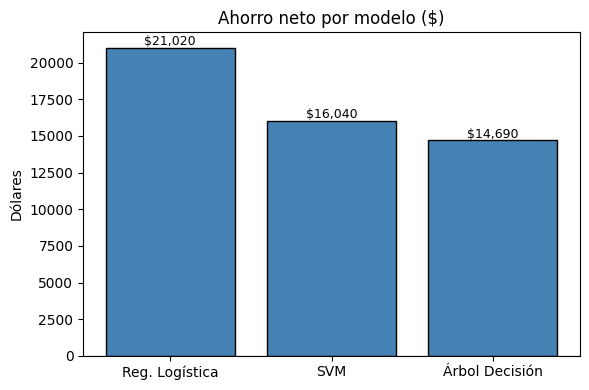

In [ ]:
# Comparación visual del ahorro neto por modelo
plt.figure(figsize=(6,4))
modelos = ['Reg. Logística','SVM','Árbol Decisión']
ahorros = [a_lr, a_svm, a_dt]
colores = ['steelblue' if a >= 0 else 'tomato' for a in ahorros]
plt.bar(modelos, ahorros, color=colores, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Ahorro neto por modelo ($)')
plt.ylabel('Dólares')
for i, v in enumerate(ahorros):
    plt.text(i, v+200, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Nota:

La Regresión Logística genera el mayor ahorro neto porque detecta más churn real. Aunque tiene más falsas alarmas que SVM, gastar 10 en una oferta innecesaria es mucho mejor que perder $100 por no detectar a tiempo.

## 8. Propuestas Prácticas

Basadas directamente en los hallazgos del modelo:

**1. Campaña de migración a contrato anual en los primeros 3 meses**  
Los clientes nuevos con contrato mes a mes son el grupo de mayor riesgo. Un descuento para migrar a contrato de 1 o 2 años en los primeros meses costaría menos que reemplazarlos después.

**2. Programa de retención para usuarios de fibra óptica sin servicios adicionales**  
Este perfil combina alto riesgo con alto gasto. Ofrecerles un servicio adicional gratis por 3 meses (seguridad online, soporte técnico) puede aumentar la percepción de valor y reducir la fuga.

**3. Lista mensual de clientes en riesgo**  
Implementar el modelo de Regresión Logística en producción para generar cada mes una lista de clientes con probabilidad de churn mayor al 70%. El equipo de retención los contacta proactivamente antes de que decidan irse.